# 📘 Suite du TP – Analyse des performances d’étudiants

🎯 **Objectif :** Approfondir la préparation du dataset pour une régression linéaire multiple en appliquant la standardisation, la réduction de dimension et la suppression des variables corrélées.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

# On recharge X et y sauvegardés à la fin du TP précédent
X = pd.read_csv("../data/X_students.csv")
y = pd.read_csv("../data/y_students.csv")["average_score"]

X.head()
# Raison : on repart de X/y déjà nettoyés et encodés (numériques) pour ne pas
# refaire tout le prétraitement -> continuité directe avec le TP précédent.

,gender,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1
1,0,0,0,1,0,0,0,0,0,0,1,0,0,1,1,0
2,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,1
3,1,1,0,0,0,0,1,0,0,0,0,0,1,0,0,1
4,1,0,0,1,0,0,0,0,0,0,1,0,0,1,0,1


## 🔄 7. Normalisation et standardisation

**0** Comprendre la notion de normalisation et de standardisation 

**21.** Standardisez toutes les colonnes numériques de `X` (moyenne 0, écart-type 1) à l’aide de `StandardScaler`.

**22.** Comparez les résultats avec une normalisation min-max (`MinMaxScaler`).

**Comprendre normalisation / standardisation**

- **Normalisation (min-max)** : ramène chaque variable dans un intervalle fixe, en général `[0, 1]`, via la formule `(x - min) / (max - min)`. Utile quand on connaît les bornes et qu'on veut préserver la forme de la distribution d'origine.
- **Standardisation (z-score)** : centre chaque variable sur une moyenne de 0 et une variance de 1, via `(x - moyenne) / écart-type`. Elle ne borne pas les valeurs dans un intervalle fixe et est plus robuste aux valeurs extrêmes (outliers) que le min-max.
- **Pourquoi c'est nécessaire ici ?** Une régression linéaire multiple (et surtout la PCA plus loin) est sensible à l'échelle des variables : sans standardisation, les colonnes avec de grandes valeurs domineraient artificiellement le modèle/les axes de variance.

In [14]:
# 21. Standardisation (StandardScaler) : moyenne 0, écart-type 1
scaler_std = StandardScaler()
X_standardized = pd.DataFrame(
    scaler_std.fit_transform(X), columns=X.columns
)

print("Moyennes après standardisation (≈ 0) :")
print(X_standardized.mean().round(6))
print("\nÉcarts-types après standardisation (≈ 1) :")
print(X_standardized.std(ddof=0).round(6))

X_standardized.head()
# Raison : StandardScaler().fit_transform() calcule (x - moyenne) / écart-type
# pour chaque colonne. On vérifie le résultat en réaffichant moyenne (≈0) et
# écart-type (≈1) de chaque colonne standardisée.

Moyennes après standardisation (≈ 0) :
gender                                            0.0
race/ethnicity_group A                           -0.0
race/ethnicity_group B                            0.0
race/ethnicity_group C                            0.0
race/ethnicity_group D                           -0.0
race/ethnicity_group E                           -0.0
parental level of education_associate's degree   -0.0
parental level of education_bachelor's degree     0.0
parental level of education_high school          -0.0
parental level of education_master's degree      -0.0
parental level of education_some college          0.0
parental level of education_some high school     -0.0
lunch_free/reduced                                0.0
lunch_standard                                   -0.0
test preparation course_completed                -0.0
test preparation course_none                      0.0
dtype: float64

Écarts-types après standardisation (≈ 1) :
gender                                

,gender,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,-0.964625,-0.312562,2.064742,-0.684419,-0.59583,-0.403473,-0.534179,2.733967,-0.493742,-0.250398,-0.540361,-0.466933,-0.741881,0.741881,-0.746748,0.746748
1,-0.964625,-0.312562,-0.484322,1.461094,-0.59583,-0.403473,-0.534179,-0.365769,-0.493742,-0.250398,1.850616,-0.466933,-0.741881,0.741881,1.339140,-1.339140
2,-0.964625,-0.312562,2.064742,-0.684419,-0.59583,-0.403473,-0.534179,-0.365769,-0.493742,3.993639,-0.540361,-0.466933,-0.741881,0.741881,-0.746748,0.746748
3,1.036672,3.199368,-0.484322,-0.684419,-0.59583,-0.403473,1.872032,-0.365769,-0.493742,-0.250398,-0.540361,-0.466933,1.347925,-1.347925,-0.746748,0.746748
4,1.036672,-0.312562,-0.484322,1.461094,-0.59583,-0.403473,-0.534179,-0.365769,-0.493742,-0.250398,1.850616,-0.466933,-0.741881,0.741881,-0.746748,0.746748


In [ ]:
# 22. Normalisation min-max (MinMaxScaler), à comparer avec la standardisation
scaler_minmax = MinMaxScaler()
X_normalized = pd.DataFrame(
    scaler_minmax.fit_transform(X), columns=X.columns
)

print("Min après normalisation (= 0) :")
print(X_normalized.min())
print("\nMax après normalisation (= 1) :")
print(X_normalized.max())

X_normalized.head()
# Comparaison :
# - StandardScaler -> moyenne 0, écart-type 1, valeurs pouvant être négatives ou >1
# - MinMaxScaler -> min 0, max 1, valeurs toujours dans [0, 1], mais distribution non centrée ni réduite.
# Avec 1000 lignes, on pourrait visualiser les distributions des colonnes standardisées
# et normalisées pour mieux comprendre l'effet de chaque méthode.

Min après normalisation (= 0) :
gender                                            0.0
race/ethnicity_group A                            0.0
race/ethnicity_group B                            0.0
race/ethnicity_group C                            0.0
race/ethnicity_group D                            0.0
race/ethnicity_group E                            0.0
parental level of education_associate's degree    0.0
parental level of education_bachelor's degree     0.0
parental level of education_high school           0.0
parental level of education_master's degree       0.0
parental level of education_some college          0.0
parental level of education_some high school      0.0
lunch_free/reduced                                0.0
lunch_standard                                    0.0
test preparation course_completed                 0.0
test preparation course_none                      0.0
dtype: float64

Max après normalisation (= 1) :
gender                                            1.0
ra

,gender,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,lunch_standard,test preparation course_completed,test preparation course_none
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


## 🔁 8. Suppression des variables trop corrélées

**0.** Comprendre la notion de corrélation linéaire. 

**23.** Calculez la **matrice de corrélation** entre les variables explicatives (`X`).

**24.** Supprimez les variables dont la corrélation dépasse un seuil (ex : > 0.9).

**25.** Réaffichez la heatmap pour valider.

**Comprendre la corrélation linéaire**

La corrélation de Pearson mesure à quel point deux variables varient ensemble de façon **linéaire**, entre -1 et 1 :
- proche de **+1** : les deux variables augmentent ensemble ;
- proche de **-1** : quand l'une augmente, l'autre diminue ;
- proche de **0** : pas de relation linéaire détectable.

**Pourquoi supprimer les variables trop corrélées ?** Deux variables très corrélées (ex. > 0.9) apportent presque la même information. Les garder toutes les deux peut créer de la **multicolinéarité**, qui rend les coefficients d'une régression linéaire instables et difficiles à interpréter, sans réellement améliorer la capacité prédictive du modèle.

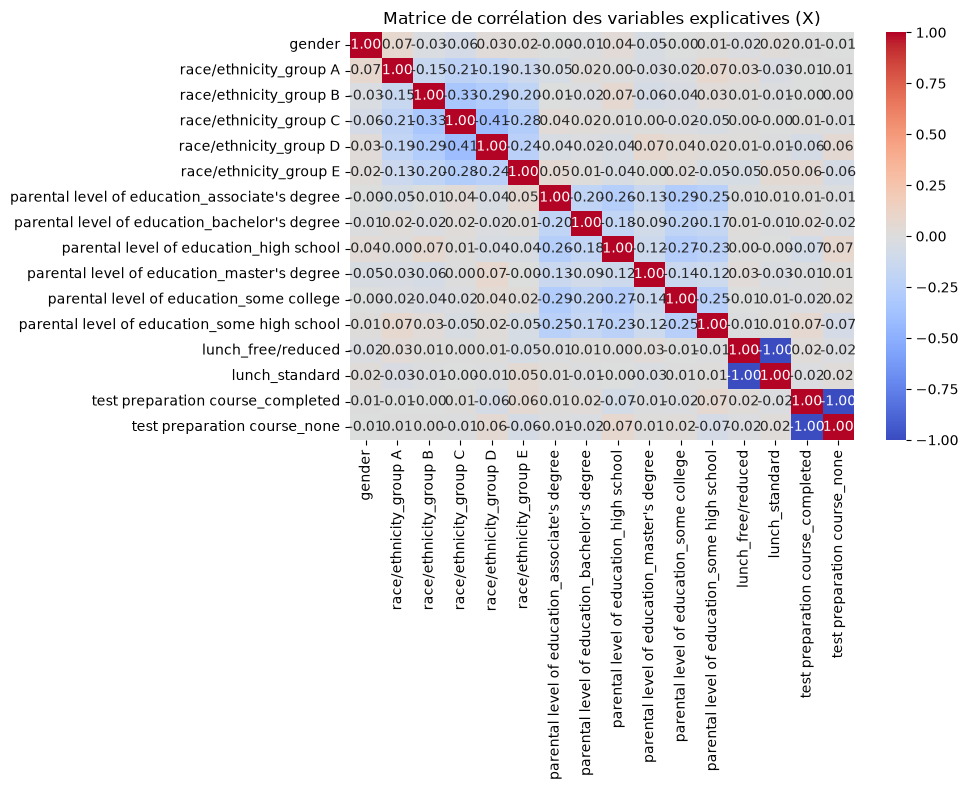

In [ ]:
# 23. Matrice de corrélation entre les variables explicatives (X)
corr_matrix = X_standardized.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matrice de corrélation des variables explicatives (X)")
plt.tight_layout()
plt.show()
# Raison : .corr() sur X (standardisé ou non, le résultat est identique car
# la corrélation est invariante par changement d'échelle linéaire).
# ⚠️ Avec 1000 lignes , plusieurs colonnes one-hot (ex. gender,
# race/ethnicity_group A, lunch_free/reduced...) sont fortement corrélées entre elles, 
# ce qui peut poser problème pour certains modèles (ex. régression linéaire).

In [17]:
# 24. Suppression des variables dont la corrélation dépasse un seuil (0.9)
threshold = 0.9

corr_abs = corr_matrix.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
print("Colonnes supprimées (corrélation > 0.9 avec une autre) :", to_drop)

X_reduced = X_standardized.drop(columns=to_drop)
print(f"\nNombre de colonnes avant : {X_standardized.shape[1]}, après : {X_reduced.shape[1]}")
X_reduced.head()
# Raison : on ne regarde que le triangle supérieur de la matrice de
# corrélation (np.triu avec k=1) pour éviter de compter deux fois chaque
# paire (corr(A,B) == corr(B,A)) et d'éviter la diagonale (corr(A,A)=1).
# Pour chaque paire dépassant le seuil, on supprime une seule des deux
# colonnes (celle rencontrée en second dans l'ordre des colonnes).

Colonnes supprimées (corrélation > 0.9 avec une autre) : ['lunch_standard', 'test preparation course_none']

Nombre de colonnes avant : 16, après : 14


,gender,race/ethnicity_group A,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_associate's degree,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_free/reduced,test preparation course_completed
0,-0.964625,-0.312562,2.064742,-0.684419,-0.59583,-0.403473,-0.534179,2.733967,-0.493742,-0.250398,-0.540361,-0.466933,-0.741881,-0.746748
1,-0.964625,-0.312562,-0.484322,1.461094,-0.59583,-0.403473,-0.534179,-0.365769,-0.493742,-0.250398,1.850616,-0.466933,-0.741881,1.339140
2,-0.964625,-0.312562,2.064742,-0.684419,-0.59583,-0.403473,-0.534179,-0.365769,-0.493742,3.993639,-0.540361,-0.466933,-0.741881,-0.746748
3,1.036672,3.199368,-0.484322,-0.684419,-0.59583,-0.403473,1.872032,-0.365769,-0.493742,-0.250398,-0.540361,-0.466933,1.347925,-0.746748
4,1.036672,-0.312562,-0.484322,1.461094,-0.59583,-0.403473,-0.534179,-0.365769,-0.493742,-0.250398,1.850616,-0.466933,-0.741881,-0.746748


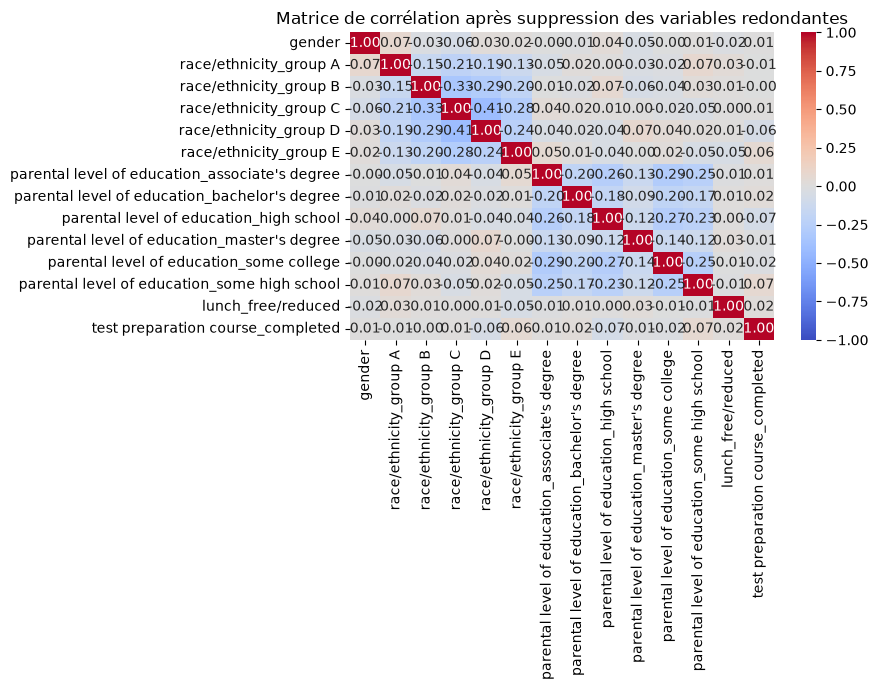

In [ ]:
# 25. Heatmap après suppression, pour validation
plt.figure(figsize=(9, 7))
sns.heatmap(X_reduced.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matrice de corrélation après suppression des variables redondantes")
plt.tight_layout()
plt.show()
# Raison : on revérifie visuellement qu'il ne reste plus de paire de
# variables avec une corrélation extrême (>0.9 ou <-0.9) dans X_reduced.

## 🧬 9. Réduction de dimension (PCA)

**0.** Comprendre la notion de réduction de dimension. Essayer de comprendre PCA globalement

**26.** Appliquez une **PCA** sur les données standardisées.

**27.** Affichez la variance expliquée par chaque composante.

**28.** Tracez un nuage de points 2D selon les 2 premières composantes.

**Comprendre la réduction de dimension et la PCA**

La **réduction de dimension** consiste à représenter les données avec moins de colonnes tout en gardant le maximum d'information (de variance). Elle est utile pour visualiser des données à plus de 2-3 dimensions, réduire le bruit/la redondance, et accélérer l'entraînement des modèles.

La **PCA (Analyse en Composantes Principales)** construit de nouveaux axes (les *composantes principales*), combinaisons linéaires des variables d'origine, **non corrélées entre elles**, et ordonnées par variance expliquée décroissante : la 1ère composante capture le plus de variance possible, la 2ème le maximum de variance restante (orthogonale à la 1ère), etc. On peut alors ne garder que les premières composantes qui résument l'essentiel de l'information.

In [ ]:
# 26. PCA sur les données standardisées
# Avec 1000 échantillons, le nombre max de composantes est min(n_samples, n_features)
n_components = min(X_standardized.shape[0], X_standardized.shape[1])
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_standardized)

X_pca_df = pd.DataFrame(
    X_pca, columns=[f"PC{i+1}" for i in range(n_components)]
)
X_pca_df
# Raison : PCA().fit_transform() standardise déjà l'orientation des axes
# (on lui passe X_standardized car la PCA est sensible à l'échelle des
# variables, comme la standardisation vue à l'étape 21).
# ⚠️ n_components est limité ici à 4 (nombre d'échantillons) au lieu des
# 12 variables d'origine, à cause du petit jeu de données.

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,1.225658,-0.418535,0.178981,1.347596,0.352516,0.393654,0.136209,0.031506,3.517556,-0.880771,0.285389,-0.124122,2.650794e-15,-3.965881e-16,-9.792508e-16,-6.775990e-15
1,-1.171903,-1.709787,0.975176,-1.403216,-1.256646,1.612929,-0.262229,-1.026304,-0.137130,-0.116253,0.268982,-0.589072,-4.580166e-15,1.166754e-16,4.944608e-16,2.612973e-15
2,1.373777,-0.218486,-0.264442,0.547830,0.253803,-0.372695,-1.611028,-0.678492,1.954788,2.518643,2.950211,1.087698,2.491199e-15,-3.965881e-16,-1.090273e-15,-8.052747e-15
3,-0.054821,2.148915,0.108085,0.533105,1.223362,-1.096664,2.377876,0.443161,-1.651103,-1.140022,2.046360,-0.234995,3.345984e-15,-2.855658e-16,1.994992e-17,3.729495e-15
4,1.428452,-0.506139,0.873708,-1.234891,-1.045657,1.458156,0.555088,-0.709544,-0.653243,-0.438674,-0.047241,1.185940,-5.002806e-15,1.585235e-16,1.994992e-17,2.494372e-15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-1.330677,-1.871396,-0.385482,-1.222060,0.904414,-0.141254,-0.762942,1.385613,0.953487,3.937682,1.797016,0.374171,9.570714e-16,5.653074e-18,5.037159e-17,-7.156990e-15
996,0.277952,2.262720,1.602149,0.747093,-0.926130,0.411357,-0.644173,1.155301,-1.307724,-0.026465,-0.758621,0.719277,-4.605988e-15,-6.352115e-17,-2.020947e-16,7.318932e-16
997,-2.322403,1.059072,1.703617,0.578768,-1.137119,0.566130,-1.461491,0.838542,-0.791612,0.295956,-0.442398,-1.055734,-4.182914e-15,-7.761365e-17,2.724162e-16,9.753937e-16
998,-0.915427,-1.544527,-1.742358,-1.674956,-0.507597,1.072321,-1.043018,-0.655714,-0.065692,-0.657354,0.153658,-1.147296,2.747306e-15,2.276977e-16,6.054831e-16,3.279106e-15


PC1 : 12.85% de variance expliquée (cumulé : 12.85%)
PC2 : 12.52% de variance expliquée (cumulé : 25.37%)
PC3 : 9.18% de variance expliquée (cumulé : 34.55%)
PC4 : 8.65% de variance expliquée (cumulé : 43.19%)
PC5 : 8.11% de variance expliquée (cumulé : 51.31%)
PC6 : 7.84% de variance expliquée (cumulé : 59.15%)
PC7 : 7.56% de variance expliquée (cumulé : 66.71%)
PC8 : 7.39% de variance expliquée (cumulé : 74.10%)
PC9 : 7.13% de variance expliquée (cumulé : 81.23%)
PC10 : 6.72% de variance expliquée (cumulé : 87.95%)
PC11 : 6.27% de variance expliquée (cumulé : 94.22%)
PC12 : 5.78% de variance expliquée (cumulé : 100.00%)
PC13 : 0.00% de variance expliquée (cumulé : 100.00%)
PC14 : 0.00% de variance expliquée (cumulé : 100.00%)
PC15 : 0.00% de variance expliquée (cumulé : 100.00%)
PC16 : 0.00% de variance expliquée (cumulé : 100.00%)


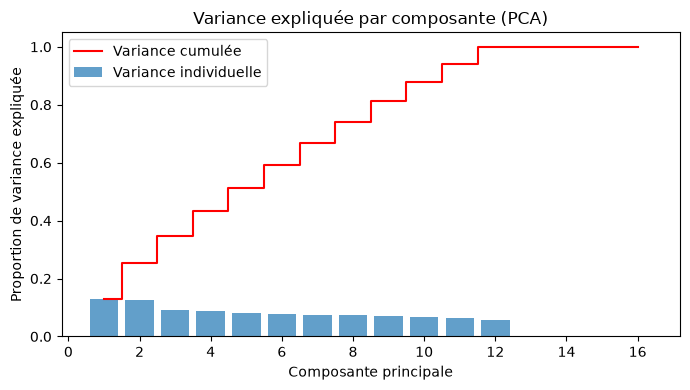

In [12]:
# 27. Variance expliquée par chaque composante
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

for i, (v, c) in enumerate(zip(explained_var, cumulative_var), start=1):
    print(f"PC{i} : {v*100:.2f}% de variance expliquée (cumulé : {c*100:.2f}%)")

plt.figure(figsize=(7, 4))
plt.bar(range(1, n_components + 1), explained_var, alpha=0.7, label="Variance individuelle")
plt.step(range(1, n_components + 1), cumulative_var, where="mid", color="red", label="Variance cumulée")
plt.xlabel("Composante principale")
plt.ylabel("Proportion de variance expliquée")
plt.title("Variance expliquée par composante (PCA)")
plt.legend()
plt.tight_layout()
plt.show()
# Raison : pca.explained_variance_ratio_ donne directement, pour chaque
# composante, la proportion de la variance totale des données qu'elle capture.
# Le graphique (éboulis + courbe cumulée) aide à choisir combien de
# composantes garder (ex. celles qui cumulent 90-95% de variance).

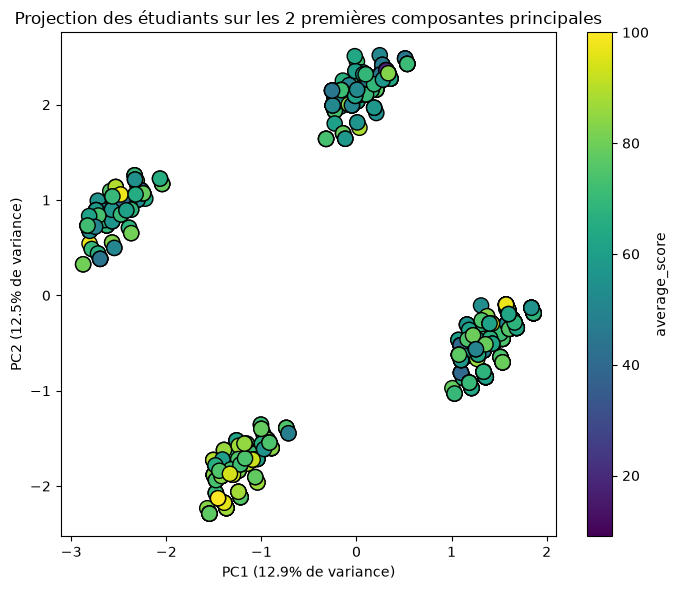

In [ ]:
# 28. Nuage de points 2D selon les 2 premières composantes principales
plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_pca_df["PC1"], X_pca_df["PC2"],
    c=y, cmap="viridis", s=120, edgecolor="black"
)
plt.colorbar(scatter, label="average_score")
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% de variance)")
plt.title("Projection des étudiants sur les 2 premières composantes principales")
plt.tight_layout()
plt.show()
# Raison : on projette chaque étudiant sur le plan (PC1, PC2), les 2 axes
# qui résument le plus de variance des données. La couleur (average_score)
# permet de voir si la séparation sur ce plan correspond à une tendance de
# performance scolaire.
# Avec 1000 échantillons, on voit si des clusters ou tendances se dégagent, 
# et si les performances scolaires sont liées à certaines combinaisons de caractéristiques.